In [1]:
import pandas as pd
import torch
import librosa
from tsai.all import *


# Load in Music Data
music_dta_3 = pd.read_csv('/Users/tarush/Desktop/STA 395/ML_Music_Genre-main/Data/music_with_labels_3_genres.csv')

# Load in base model
net = InceptionTime(1, 10)

net_3 = InceptionTime(1, 3)

# Create additional variables 
path = '/Users/tarush/Desktop/STA 395/ML_Music_Genre-main/Data/Music/genres_original' 
music_dta_3["Audio_pth"] = path + "/" + music_dta_3["Label"] + "/" + music_dta_3["Audio"]
music_dta_3['Audio_y_dta'] = (music_dta_3['Audio_pth'].map(librosa.load))

Python(9629) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(9630) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [2]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

bsize = 32

# Grab Middle Few Seconds of Song
def grab_first(inp):
    return (inp[0])[300000:360000]

# Grab time series data of amplitudes
music_dta_3['Audio_y_dta_arr'] = music_dta_3['Audio_y_dta'].apply(grab_first)

# Split data to create training, validation, and testing set
music_dta_3_train, music_dta_3_test = train_test_split(music_dta_3, test_size=0.25)


# tensor data for train loader
music_dta_3_train['Audio_y_dta_arr'] = music_dta_3_train['Audio_y_dta_arr'].apply(torch.Tensor)
music_dta_3_train['Label_num'], unique_categories = pd.factorize(music_dta_3_train["Label"]) # Stack Overflow
music_dta_3_train_y = torch.Tensor(tuple(music_dta_3_train["Label_num"].to_numpy()))
music_dta_3_train_X = torch.stack(tuple(music_dta_3_train['Audio_y_dta_arr'])).unsqueeze(1) # convert to 3d

train_loader = DataLoader(TensorDataset(music_dta_3_train_X.type(torch.FloatTensor), music_dta_3_train_y.type(torch.LongTensor)), batch_size=bsize)


In [3]:
# tensor data for test loader
music_dta_3_test['Audio_y_dta_arr'] = music_dta_3_test['Audio_y_dta_arr'].apply(torch.Tensor)
music_dta_3_test['Label_num'], unique_categories = pd.factorize(music_dta_3_test["Label"]) # Stack Overflow
music_dta_3_test_y = torch.Tensor(tuple(music_dta_3_test["Label_num"].to_numpy()))
music_dta_3_test_X = torch.stack(tuple(music_dta_3_test['Audio_y_dta_arr'])).unsqueeze(1) # convert to 3d

test_loader = DataLoader(TensorDataset(music_dta_3_test_X.type(torch.FloatTensor), music_dta_3_test_y.type(torch.LongTensor)), batch_size=bsize)

In [4]:
## Hyperparams
# Network model
torch.manual_seed(20) # For reproduction purposes
net_3 = InceptionTime(1, 3)
epochs = 20
lrate = 0.0005

## Cost Function
from torch import nn
cost_fn = nn.CrossEntropyLoss()

## Optimizer using ADAM, a more flexible algorithm than SGD this time)
optimizer = torch.optim.Adam(net_3.parameters(), lr=lrate)

## Initial values for cost tracking
track_cost = np.zeros(epochs)
cur_cost = 0.0


## Loop through the data
for epoch in range(epochs):
    print(epoch)
    cur_cost = 0.0
    correct = 0.0
    val_cur_cost = 0.0
    
    ## train_loader is iterable and keeps track of batch numbers
    for i, data in enumerate(train_loader, 0):
        
        ## The input tensor and labels tensor for the current batch
        inputs, labels = data
        
        ## Clear the gradient from the previous batch
        optimizer.zero_grad()
        
        ## Provide the input tensor into the network to get outputs
        outputs = net_3(inputs)
        
        ## Calculate the cost for the current batch
        ## nn.Softmax is used because net outputs prediction scores and our cost function expects probabilities and labels
        cost = cost_fn(nn.Softmax(dim=1)(outputs), labels)
        
        ## Calculate the gradient
        cost.backward()
        
        ## Update the model parameters using the gradient
        optimizer.step()
        
        ## Track the current cost (accumulating across batches)
        cur_cost += cost.item()

    
    ## Store the accumulated cost at each epoch
    track_cost[epoch] = cur_cost

0


KeyboardInterrupt: 

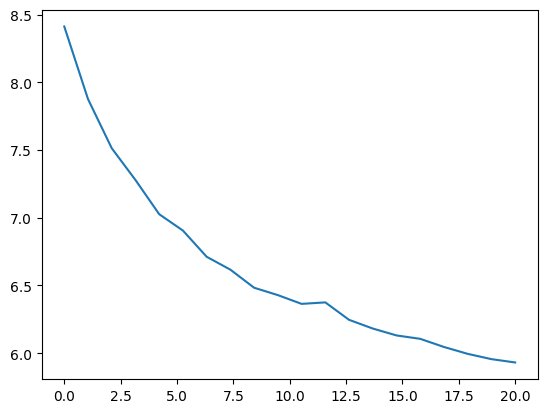

In [12]:
## Print the cost curve
import matplotlib.pyplot as plt
plt.plot(np.linspace(0, epochs, epochs), track_cost)
plt.show()

In [13]:
## Initialize objects for counting correct/total 
correct = 0
total = 0

# Specify no changes to the gradient in the subsequent steps (since we're not using these data for training)
with torch.no_grad():
    for data in train_loader:
        # Current batch of data
        images, labels = data
        
        # pass each batch into the network
        outputs = net_3(images)
        
        # the class with the maximum score is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        
        # add size of the current batch
        total += labels.size(0)
        
        # add the number of correct predictions in the current batch
        correct += (predicted == labels).sum().item()

## Calculate and print the proportion correct
print(correct/total)

0.88


In [14]:
## Initialize objects for counting correct/total 
correct = 0
total = 0

# Specify no changes to the gradient in the subsequent steps (since we're not using these data for training)
with torch.no_grad():
    for data in test_loader:
        # Current batch of data
        input, labels = data
        
        # pass each batch into the network
        outputs = net_3(input)
        
        # the class with the maximum score is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        
        # add size of the current batch
        total += labels.size(0)
        
        # add the number of correct predictions in the current batch
        correct += (predicted == labels).sum().item()

## Calculate and print the proportion correct
print(correct/total)

0.29333333333333333
